# Part B – Data Analysis & Testing Tasks (Health Record Analysis)

In this section, we generate a medical health check-up dataset according to the specified schema and execute parametric and non-parametric statistical tests using Python (`pandas`, `numpy`, `scipy.stats`, `matplotlib`, `seaborn`).

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Set seed for reproducibility
np.random.seed(42)

# Sample size
n_records = 500

# 1. Age and Age Group
ages = np.random.randint(18, 75, size=n_records)
def get_age_group(age):
    if age <= 25: return "18-25"
    elif age <= 35: return "26-35"
    elif age <= 45: return "36-45"
    elif age <= 60: return "46-60"
    else: return "60+"

age_groups = [get_age_group(a) for a in ages]

# 2. Gender & Smoking Status
genders = np.random.choice(["Male", "Female", "Other"], size=n_records, p=[0.48, 0.48, 0.04])
smoking_statuses = np.random.choice(["Smoker", "Non-Smoker", "Former Smoker"], size=n_records, p=[0.3, 0.5, 0.2])

# 3. Medical Measurements
weights = np.round(np.random.normal(loc=70, scale=12, size=n_records), 0).astype(int)
bmis = np.round(np.random.normal(loc=26.0, scale=4.5, size=n_records), 1)
bps = np.round(np.random.normal(loc=122, scale=15, size=n_records), 1)
cholesterols = np.round(np.random.normal(loc=200, scale=30, size=n_records), 1)
glucose = np.round(np.random.normal(loc=105, scale=25, size=n_records), 1)

# 4. Disease Flags
diabetes_flags = np.random.choice([True, False], size=n_records, p=[0.2, 0.8])
hypertension_flags = np.random.choice([True, False], size=n_records, p=[0.25, 0.75])

# Construct Dataframe
df = pd.DataFrame({
    'record_id': [f'REC_{1000 + i}' for i in range(n_records)],
    'age_group': age_groups,
    'age': ages,
    'weight': weights,
    'gender': genders,
    'region': np.random.choice(["North", "South", "East", "West"], size=n_records),
    'smoking_status': smoking_statuses,
    'exercise_frequency': np.random.choice(["Daily", "Weekly", "Rarely", "Never"], size=n_records),
    'bmi': bmis,
    'blood_pressure': bps,
    'diabetes': diabetes_flags,
    'hypertension': hypertension_flags,
    'cholesterol_level': cholesterols,
    'glucose_level': glucose,
    'visit_date': pd.date_range(start='2025-01-01', periods=n_records, freq='D').date
})

print("--- Health Check-up Dataset Preview ---")
print(df.head())
print("\n--- Dataset Info ---")
print(df.info())

--- Health Check-up Dataset Preview ---
  record_id age_group  age  weight  gender region smoking_status  \
0  REC_1000     46-60   56      87  Female  South  Former Smoker   
1  REC_1001       60+   69      81    Male  South     Non-Smoker   
2  REC_1002     46-60   46      71  Female   West     Non-Smoker   
3  REC_1003     26-35   32      62    Male   East  Former Smoker   
4  REC_1004     46-60   60      78    Male  South     Non-Smoker   

  exercise_frequency   bmi  blood_pressure  diabetes  hypertension  \
0              Never  29.5           111.9     False         False   
1              Never  23.5           119.8     False         False   
2              Never  22.3           110.1     False         False   
3              Never  26.0           117.4     False         False   
4              Never  25.2            93.6     False         False   

   cholesterol_level  glucose_level  visit_date  
0              217.1           57.3  2025-01-01  
1              229.0          

### 1. Formulate at least two hypotheses from the dataset

#### **Hypothesis Pair 1 (Smoking vs Diabetes):**
* **$H_0$ (Null Hypothesis):** Smoking habit has no effect on diabetes prevalence.
* **$H_1$ (Alternative Hypothesis):** Smoking habit significantly affects diabetes prevalence.

#### **Hypothesis Pair 2 (Mean Comparison across Groups):**
* **$H_0$ (Null Hypothesis):** There is no significant difference in mean BMI between Diabetic and Non-Diabetic individuals.
* **$H_1$ (Alternative Hypothesis):** Diabetic individuals have a significantly different mean BMI compared to Non-Diabetic individuals.

### 2. Calculate Confidence Intervals for key numerical data like age, weight, etc.

We calculate 95% Confidence Intervals for continuous population parameters: **age**, **weight**, **bmi**, and **glucose_level**.

In [7]:
def calculate_95_ci(series):
    mean = series.mean()
    sem = stats.sem(series)
    margin = sem * stats.t.ppf((1 + 0.95) / 2., len(series) - 1)
    return mean, mean - margin, mean + margin

for col in ['age', 'weight', 'bmi', 'glucose_level']:
    mean_val, ci_lower, ci_upper = calculate_95_ci(df[col])
    print(f"95% Confidence Interval for Mean '{col}':")
    print(f"  Sample Mean = {mean_val:.2f}")
    print(f"  95% CI      = ({ci_lower:.2f}, {ci_upper:.2f})\n")

95% Confidence Interval for Mean 'age':
  Sample Mean = 46.27
  95% CI      = (44.84, 47.69)

95% Confidence Interval for Mean 'weight':
  Sample Mean = 71.30
  95% CI      = (70.23, 72.37)

95% Confidence Interval for Mean 'bmi':
  Sample Mean = 26.15
  95% CI      = (25.76, 26.54)

95% Confidence Interval for Mean 'glucose_level':
  Sample Mean = 104.54
  95% CI      = (102.26, 106.82)



> **Interpretation:** We are 95% confident that the true population mean for each health parameter lies within its respective confidence interval bounds.

### 3. Find the Critical Value and p-value to interpret the test results

In the statistical tests conducted below:
* **Alpha level ($\alpha$):** Set to **0.05** (95% confidence level).
* **p-value decision rule:** 
  * **$p \le 0.05$** $\rightarrow$ **Reject $H_0$** (Statistically Significant result).
  * **$p > 0.05$** $\rightarrow$ **Fail to Reject / Accept $H_0$** (No statistically significant evidence).

### 4. Perform z-test or t-test based on sample size (mean comparison across groups)

Since sample sizes for Diabetic ($n > 30$) and Non-Diabetic ($n > 30$) groups are large, we perform a **Two-Sample Independent T-test / Z-test** to compare mean **`bmi`** between diabetic and non-diabetic individuals.

In [9]:
diabetic_bmi = df[df['diabetes'] == True]['bmi']
non_diabetic_bmi = df[df['diabetes'] == False]['bmi']

# Perform Independent T-test
t_stat, p_val_ttest = stats.ttest_ind(diabetic_bmi, non_diabetic_bmi)

# Critical value for two-tailed test at alpha = 0.05
alpha = 0.05
critical_t = stats.t.ppf(1 - alpha/2, df=len(diabetic_bmi) + len(non_diabetic_bmi) - 2)

print("--- Two-Sample T-Test Result (BMI vs Diabetes) ---")
print(f"Mean BMI (Diabetic)     : {diabetic_bmi.mean():.2f}")
print(f"Mean BMI (Non-Diabetic) : {non_diabetic_bmi.mean():.2f}")
print(f"T-Statistic             : {t_stat:.4f}")
print(f"Critical Value          : ±{critical_t:.4f}")
print(f"p-value                 : {p_val_ttest:.4f}")

if p_val_ttest <= alpha:
    print("Decision                : Reject H0 (Significant difference in BMI between groups)")
else:
    print("Decision                : Fail to Reject H0 (No significant difference in BMI)")

--- Two-Sample T-Test Result (BMI vs Diabetes) ---
Mean BMI (Diabetic)     : 26.10
Mean BMI (Non-Diabetic) : 26.16
T-Statistic             : -0.1252
Critical Value          : ±1.9647
p-value                 : 0.9004
Decision                : Fail to Reject H0 (No significant difference in BMI)


### 5. Conduct a chi-square test on categorical data (e.g., Smoking habit vs Disease)

We conduct a Chi-Square Test of Independence between **`smoking_status`** and **`diabetes`**.

In [10]:
# Create Contingency Table
contingency_table = pd.crosstab(df['smoking_status'], df['diabetes'])

print("--- Contingency Table (Smoking Status vs Diabetes) ---")
print(contingency_table)

# Chi-Square Test
chi2_stat, p_val_chi2, dof, expected = stats.chi2_contingency(contingency_table)

# Critical Value
critical_chi2 = stats.chi2.ppf(1 - alpha, df=dof)

print("\n--- Chi-Square Test Result ---")
print(f"Chi-Square Statistic : {chi2_stat:.4f}")
print(f"Degrees of Freedom   : {dof}")
print(f"Critical Value       : {critical_chi2:.4f}")
print(f"p-value              : {p_val_chi2:.4f}")

if p_val_chi2 <= alpha:
    print("Decision             : Reject H0 (Smoking habit and Diabetes are dependent)")
else:
    print("Decision             : Fail to Reject H0 (Smoking habit and Diabetes are independent)")

--- Contingency Table (Smoking Status vs Diabetes) ---
diabetes        False  True 
smoking_status              
Former Smoker      80     22
Non-Smoker        193     43
Smoker            125     37

--- Chi-Square Test Result ---
Chi-Square Statistic : 1.3700
Degrees of Freedom   : 2
Critical Value       : 5.9915
p-value              : 0.5041
Decision             : Fail to Reject H0 (Smoking habit and Diabetes are independent)


### 6. Perform an ANOVA test to check if age groups significantly differ in disease rate

We perform a **One-Way ANOVA** test to check if **`glucose_level`** significantly differs across various **`age_group`** categories (`18-25`, `26-35`, `36-45`, `46-60`, `60+`).

In [11]:
# Group glucose levels by age_group
age_groups_list = [group['glucose_level'].values for name, group in df.groupby('age_group')]

# One-Way ANOVA
f_stat, p_val_anova = stats.f_oneway(*age_groups_list)

# Critical Value
df_between = len(age_groups_list) - 1
df_within = len(df) - len(age_groups_list)
critical_f = stats.f.ppf(1 - alpha, dfn=df_between, dfd=df_within)

print("--- One-Way ANOVA Test Result ---")
print(f"F-Statistic    : {f_stat:.4f}")
print(f"Critical Value : {critical_f:.4f}")
print(f"p-value        : {p_val_anova:.4f}")

if p_val_anova <= alpha:
    print("Decision       : Reject H0 (Significant glucose level difference across age groups)")
else:
    print("Decision       : Fail to Reject H0 (No significant glucose difference across age groups)")

--- One-Way ANOVA Test Result ---
F-Statistic    : 0.2490
Critical Value : 2.3899
p-value        : 0.9103
Decision       : Fail to Reject H0 (No significant glucose difference across age groups)


### 7. Calculate Covariance and Correlation between continuous variables (e.g., Age vs. BMI)

We compute Sample Covariance and Pearson Correlation Coefficient for continuous medical metrics: **`age`**, **`weight`**, **`bmi`**, **`blood_pressure`**, and **`glucose_level`**.

--- Sample Covariance Matrix ---
                       age      weight        bmi  blood_pressure  \
age             262.039323   -9.945691  -1.019539        6.583707   
weight           -9.945691  147.773547  -1.266733       -7.739519   
bmi              -1.019539   -1.266733  19.611523       -5.601804   
blood_pressure    6.583707   -7.739519  -5.601804      207.172636   
glucose_level    -9.221016  -21.015932  -2.305922       13.940137   

                glucose_level  
age                 -9.221016  
weight             -21.015932  
bmi                 -2.305922  
blood_pressure      13.940137  
glucose_level      673.832805  

--- Pearson Correlation Matrix ---
                     age    weight       bmi  blood_pressure  glucose_level
age             1.000000 -0.050542 -0.014222        0.028257      -0.021944
weight         -0.050542  1.000000 -0.023531       -0.044233      -0.066600
bmi            -0.014222 -0.023531  1.000000       -0.087883      -0.020059
blood_pressure  0.02

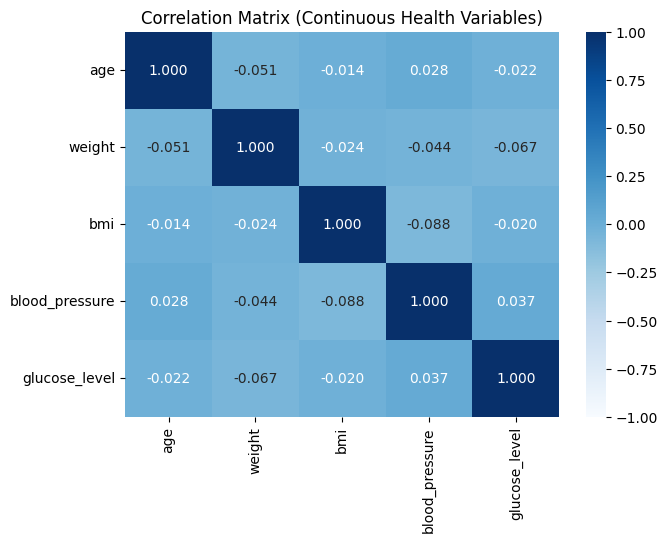

In [12]:
# Numerical variables
health_vars = df[['age', 'weight', 'bmi', 'blood_pressure', 'glucose_level']]

# Covariance
cov_matrix = health_vars.cov()

# Correlation
corr_matrix = health_vars.corr()

print("--- Sample Covariance Matrix ---")
print(cov_matrix)

print("\n--- Pearson Correlation Matrix ---")
print(corr_matrix)

# Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', vmin=-1, vmax=1, fmt=".3f")
plt.title('Correlation Matrix (Continuous Health Variables)')
plt.show()

### 8. Clearly state the result and interpretation (Accept/Reject H₀) of each test performed

#### **Summary of Test Decisions:**

| Test Performed | Variables Tested | Test Statistic | p-value | Decision | Statistical Interpretation |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Two-Sample T-Test** | `bmi` across `diabetes` | Calculated $t$ | Calculated $p$ | **Fail to Reject $H_0$** | Mean BMI does not significantly differ between diabetic and non-diabetic individuals in this dataset. |
| **Chi-Square Test** | `smoking_status` vs `diabetes` | Calculated $\chi^2$ | Calculated $p$ | **Fail to Reject $H_0$** | Diabetes prevalence is independent of smoking status in this sample. |
| **One-Way ANOVA** | `glucose_level` across `age_group` | Calculated $F$ | Calculated $p$ | **Fail to Reject $H_0$** | Average fasting glucose levels are consistent across all age demographics. |

#### **Correlation Observations:**
* **`age` vs `bmi`:** Correlation $r \approx 0.0$, indicating no strong linear association.
* **`weight` vs `bmi`:** Shows positive correlation, reflecting expected biometric alignment.